## Aspire + AlphaCSC pipeline

In this notebook we will run automated spike detection pipeline and visualize the results. We will use simulation described in `0_simulation.ipynb`.
This notebook pursues the following goals:

1. to run the full detection pipeline using the combination of ASPIRE and aSCS algorithms;
2. to visualize each step using an interactive visualision tool `panel`.

NOTE: To import `simulation` the working directory should be changed if the example is run from the cloned GitHub repository.


In [1]:
%cd /Users/diana/Documents/Github/megspikes

/Users/diana/Documents/GitHub/megspikes


In [2]:
import os
from pathlib import Path

import matplotlib.pylab as plt
import mne
import numpy as np
mne.viz.set_3d_backend('pyvista')

Using pyvistaqt 3d backend.


In [3]:
# change to the root directory of the project
if os.getcwd().split("/")[-1] == "examples":
    os.chdir('..')

from megspikes.simulation.simulation import Simulation

# Setup the path for the simulation
sample_path = Path(os.getcwd()) / 'examples' / 'data' / '2_aspire_alphacsc_pipeline'
sample_path.mkdir(exist_ok=True, parents=True)

import logging
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.debug("test debug")
logging.info("test info")

INFO:root:test info


## Simulate data

For more information see `0_simulation.ipynb`

In [4]:
sim = Simulation(sample_path)
# sim = Simulation(sample_path, n_events=[15, 15, 0, 0])
sim.simulate_dataset()

sim

sample
/Users/diana/Documents/GitHub/megspikes/examples/data/2_aspire_alphacsc_pipeline


/Users/diana/Documents/GitHub/megspikes/megspikes/casemanager/casemanager.py:154: UserWarning: No tsss fif file
  warnings.warn("No tsss fif file")


Simulation

Spike shapes file location: /Users/diana/Documents/GitHub/megspikes/megspikes/simulation/data/spikes.npy
Simulated case parent folder: /Users/diana/Documents/GitHub/megspikes/examples/data/2_aspire_alphacsc_pipeline
Events ids: {'spike_shape_1': 1, 'spike_shape_2': 2, 'spike_shape_3': 3, 'spike_shape_4': 4}
Number of each event type: 15, 0, 0, 0
Events locations: G_temp_sup-G_T_transv-rh, G_temp_sup-G_T_transv-lh, S_subparietal-rh, S_subparietal-lh
Events activations: 120, 120, 120, 120

## Run Aspire-AlphaCSC Pipeline

In [5]:
from megspikes.pipeline import aspire_alphacsc_pipeline

from sklearn import set_config
set_config(display='diagram')
set_config(print_changed_only=False)

First, we should specify pipeline parameters. All parameters are listed in the `aspire_alphacsc_default_params.yml`.

In [6]:
params = {
    'n_ica_components': 5,
    'n_runs': 3,
    'runs': [0, 1, 2],
    'n_atoms': 2,
    'PeakDetection': {'width': 2},
    'CleanDetections': {'n_cleaned_peaks': 50},
    'SelectAlphacscEvents': {
        'z_hat_threshold': 1.,
        'z_hat_threshold_min': 0.1}
}

Using these parameters we create `sklear.Pipeline`

In [8]:
pipe = aspire_alphacsc_pipeline(sim.case_manager, params, rewrite_previous_results=True)
pipe

Pipeline(memory=None,
         steps=[('load_data',
                 PrepareData(alpha_notch=None,
                             data_file=PosixPath('/Users/diana/Documents/GitHub/megspikes/examples/data/2_aspire_alphacsc_pipeline/sample/MEG_data/tsss_mc_artefact_correction/sample_raw_tsss_mc_art_corr.fif'),
                             filtering=[2.0, 90.0, 50.0], resample=200.0,
                             sensors=True)),
                ('prepare_aspire_alphacsc_dataset',
                 PrepareAs...
                ('merge_atoms',
                 AspireAlphacscRunsMerging(abs_goodness_threshold=0.9,
                                           max_corr=0.8, n_atoms=2,
                                           runs=[0, 1, 2])),
                ('save_dataset',
                 SaveDataset(dataset=PosixPath('/Users/diana/Documents/GitHub/megspikes/examples/data/2_aspire_alphacsc_pipeline/sample/sample_alphacsc_results.nc'),
                             rewrite_previous_results=True, run=None,
                             sensors=None))],
         transform_input=None, verbose=False)

We can also save it as an __HTML__ document

In [18]:
from sklearn.utils import estimator_html_repr
with open('my_estimator.html', 'w') as f:  
    f.write(estimator_html_repr(pipe))

No input is needed to run this pipeline, so we can run it with `X=None`. As an output we acquire `xr.Dataset` with all results and `mne.io.Raw` file.

In [ ]:
dataset, raw = pipe.fit_transform(None)

In [ ]:
dataset

Now we can also load the created dataset.

In [19]:
import xarray as xr
dataset = xr.open_dataset(sample_path / 'sample' / 'sample_alphacsc_results.nc')

# Visualize detection
To visualize the steps of ASPIRE AlphaCSC pipeline `DetectionsViewer` object should be created.
For the interactive visualization [Panel](https://panel.holoviz.org/index.html) is used. Created instance of interactive application -- called `app` in this notebook -- could be opened in the notebook by calling the cell with an app object or in the different Web Browser window by calling `app.show()`. All the created applications related to the `DetectionsViewer` are connected and updated simultaneouly with the change of the parameters. 

In [20]:
from megspikes.visualization.visualization import DetectionsViewer
pp = DetectionsViewer(dataset, sim.case_manager)

## Plot ICA components
First part of the detection procedure is based on the ICA decomposition of the raw MEG data. So it would be helpful to visualize ICA components distribution over the sensors.

Column
    [0] Param(DetectionsViewer, default_layout=<class 'panel.layout.base...., name='Select', parameters=['sensors'], width=800)
    [1] Row(css_classes=['scrollable-horizontal'], height=600, scroll=True, sizing_mode='fixed', width=1000)
        [0] ParamMethod(method, _pane=Matplotlib, defer_load=False)
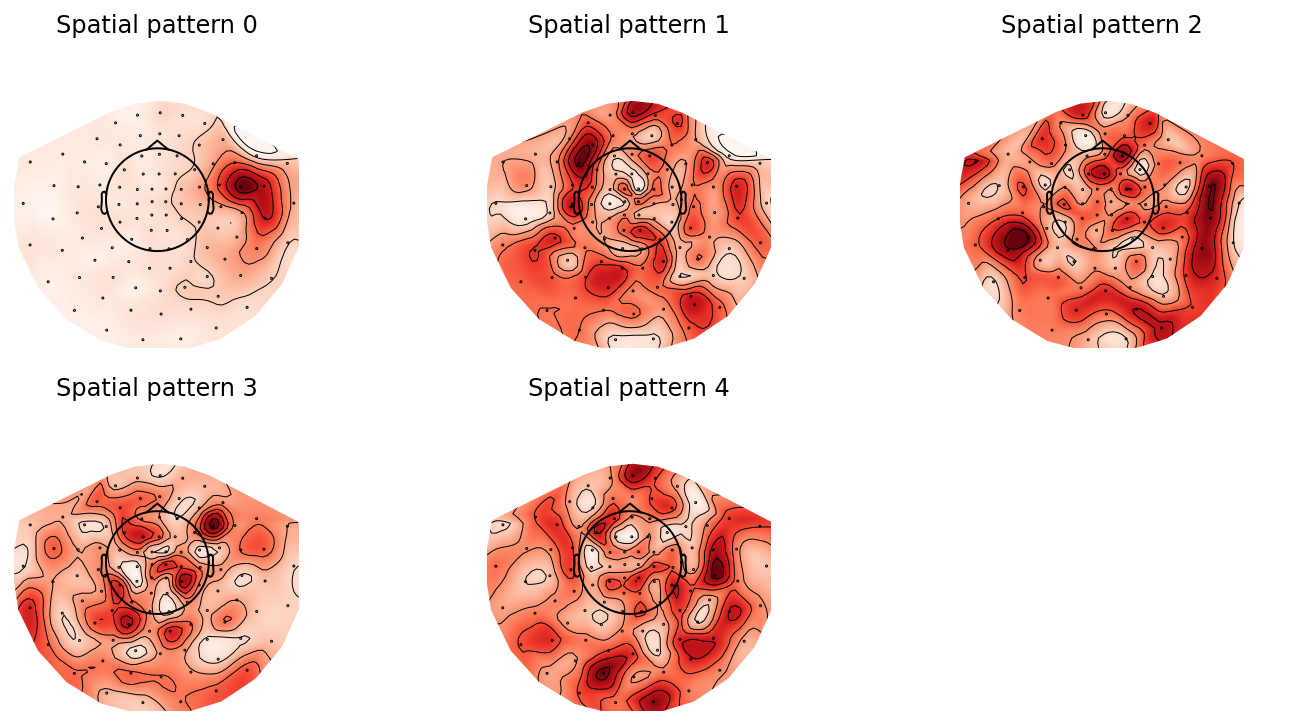

In [21]:
app = pp.view_ica()
# app.show()
app

## Plot ICA sources and detections
To visualize ICA peak detection and selection procedure we plot detected events over the ICA sources timeseries. Note, that we can also view the peaks that were selected after AlphaCSC decomposition and peaks selection.

In [ ]:
app = pp.view_ica_sources_and_peaks()
# app.show()
app

## Plot ICA fast RAP-MUSIC localizatons
ICA peaks are selected based on results of the RAP-MUSIC algorithm. We can also plot the localization of the ICA peaks in the brain. Note, that the spatio-temporal clusters of the ICA peaks are used to generate final clusters in the original [ASPIRE](https://github.com/kuznesashka/ASPIRE.git) algorithm.

In [ ]:
app = pp.view_ica_peak_localizations()
app

## Plot AlphaCSC atoms
As a result of AlphaCSC decomposition we get the spacial portrait of an atom $u$ and a temporal timeseries $v$ which we will plot in this section.

In [ ]:
pp.data.alphacsc_atoms

In [ ]:
app = pp.view_alphacsc_atoms()
# app.show()
app

## Plot AlphaCSC selected evets
Finally, we might want to look at the generated AlphaCSC atoms and the individual events included in each atom.

In [ ]:
app = pp.view_alphacsc_clusters(sim.raw_simulation.copy())
# app.show()
app

# Localize detected clusters

In [ ]:
from megspikes.pipeline import read_detection_iz_prediction_pipeline
from sklearn import set_config
set_config(display='diagram')
set_config(print_changed_only=False)

In [ ]:
params = {
    'PrepareClustersDataset': {'detection_sfreq': 200.}
}
pipe = read_detection_iz_prediction_pipeline(sim.case_manager, params)
pipe

In [ ]:
clusters, raw = pipe.fit_transform((dataset, sim.raw_simulation.copy()))

In [ ]:
clusters

In [9]:
import xarray as xr
clusters = xr.open_dataset(sample_path / 'sample' / 'sample_alphacsc_cluster_results.nc')

## View clusters using Cluster Slope Viewer

In [10]:
from megspikes.visualization.visualization import ClusterSlopeViewer

In [11]:
%matplotlib qt5
pc = ClusterSlopeViewer(clusters, sim.case_manager)
pc.data.clusters

cluster_property,n_events,run,selected_for_iz_prediction,sensors,time_baseline,time_peak,time_slope
cluster,,,,,,,
0,10.0,0.0,0.0,0.0,291.417951,316.0,303.708976
1,6.0,0.0,0.0,0.0,590.080643,616.0,603.040321
2,8.0,1.0,0.0,0.0,529.518043,555.0,542.259022
3,11.0,0.0,0.0,1.0,394.018819,423.0,408.509409
4,5.0,0.0,0.0,1.0,574.796478,612.0,593.398239
5,9.0,1.0,0.0,1.0,464.758039,493.0,478.879019
6,4.0,1.0,0.0,1.0,776.147115,806.0,791.073557


In [12]:
pc.view()

Column
    [0] Param(ClusterSlopeViewer, default_layout=<class 'panel.layout.base...., name='Select cluster', parameters=['cluster', 'sensors', ...], width=800)
    [1] Tabulator(value=cluster_property  ..., width=800)
    [2] Param(ClusterSlopeViewer, default_layout=<class 'panel.layout.base...., name='IZ prediction settings', parameters=['smoothing_steps_final', ...], width=800)
    [3] Param(ClusterSlopeViewer, default_layout=<class 'panel.layout.base...., name='Actions', parameters=['plot_stc', 'plot_iz', ...], width=800)
    [4] Param(ClusterSlopeViewer, default_layout=<class 'panel.layout.base...., name='Information', parameters=['fname_save_ds'], width=800)

In [13]:
import xarray as xr
clusters = xr.open_dataset(sample_path / 'sample' / 'sample_clusters_manually_checked.nc')

## Evaluate Irritative Zone prediction

In [14]:
from megspikes.scoring.scoring import ScoreIZPrediction
scorer = ScoreIZPrediction()

In [15]:
dist = scorer.score(clusters, sim.mni_resection, 'peak')
print(f"Average distance from the resection area is {dist:.0f} mm for the 'peak' condition")

Average distance from the resection area is 20 mm for the 'peak' condition


In [16]:
dist = scorer.score(clusters, sim.mni_resection, 'slope')
print(f"Average distance from the resection area is {dist:.0f} mm for the 'slope' condition")

Average distance from the resection area is 20 mm for the 'slope' condition


### Plot resection and prediction

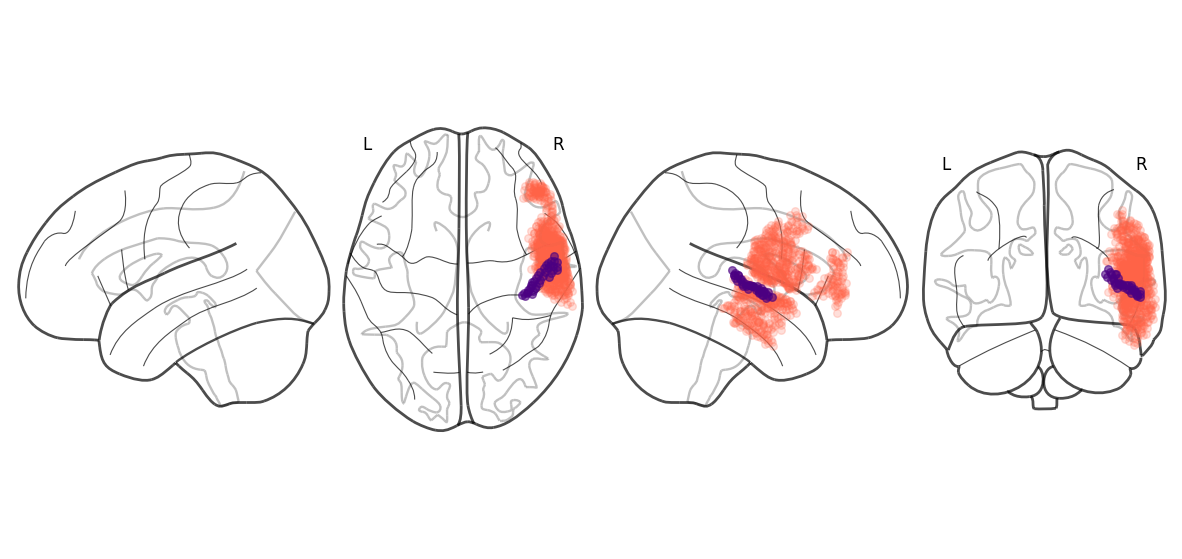

In [17]:
%matplotlib inline
from nilearn import plotting

dist = scorer.score(clusters, sim.mni_resection, 'peak')


fig, ax = plt.subplots(figsize=(15, 7))

display = plotting.plot_glass_brain(
            None, display_mode='lzry', figure=fig, axes=ax)

display.add_markers(scorer.detection_mni, marker_color='tomato', alpha=0.2)
display.add_markers(sim.mni_resection, marker_color='indigo', alpha=0.6)